# Statistical Risk Engine

This notebook implements the statistical risk modeling layer.

Components:
- Log returns
- Rolling volatility
- EWMA volatility
- Covariance estimation
- Portfolio variance
- Forecast vs realized volatility backtesting

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.risk_metrics import (
    compute_log_returns,
    rolling_volatility,
    ewma_volatility,
    ewma_covariance,
    portfolio_volatility
)

plt.style.use("seaborn-v0_8")

In [2]:
assets = ["AAPL", "MSFT", "SPY", "BTC-USD", "GLD"]
start_date = "2015-01-01"

prices = pd.DataFrame()

for ticker in assets:
    data = yf.download(ticker, start=start_date, progress=False)
    prices[ticker] = data["Close"][ticker]

prices.dropna(inplace=True)

In [3]:
returns = compute_log_returns(prices)

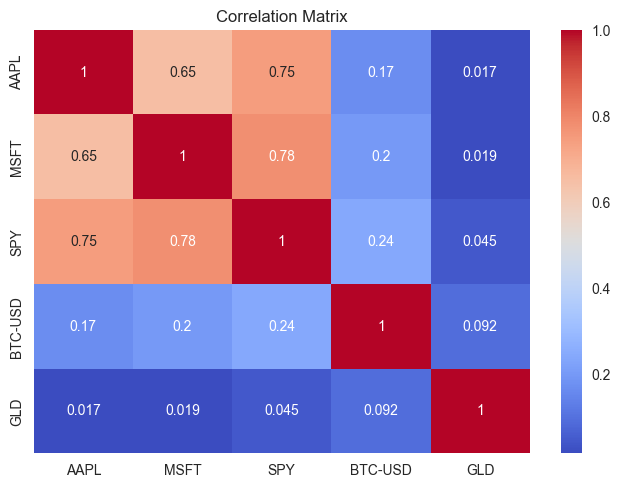

In [4]:
cov_matrix = returns.cov()
corr_matrix = returns.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [5]:
weights = np.ones(len(returns.columns)) / len(returns.columns)

portfolio_var = np.dot(weights.T, np.dot(cov_matrix, weights))
portfolio_vol = np.sqrt(portfolio_var) * np.sqrt(252)

portfolio_vol

np.float64(0.21313831989271662)

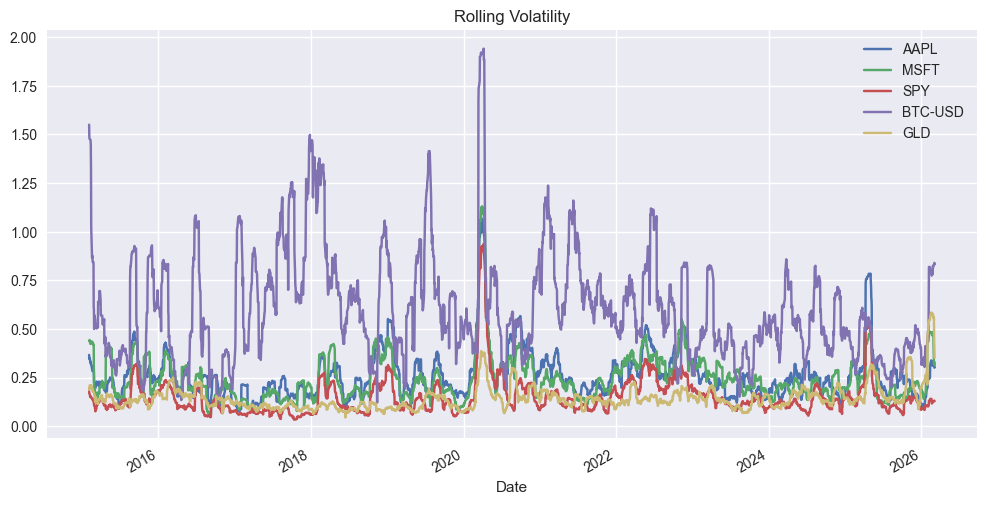

In [6]:
rolling_vol = rolling_volatility(returns)

rolling_vol.plot(figsize=(12,6))
plt.title("Rolling Volatility")
plt.show()

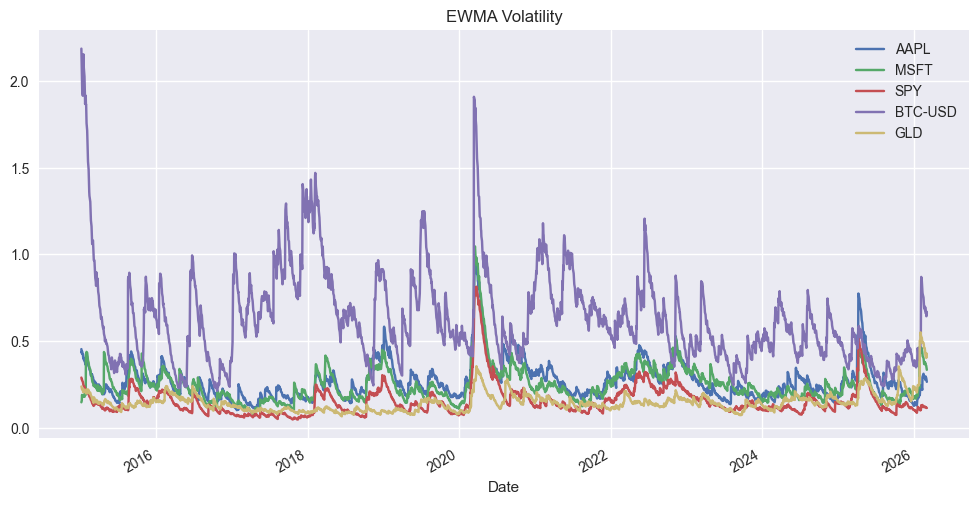

In [7]:
ewma_vol = ewma_volatility(returns)

ewma_vol.plot(figsize=(12,6))
plt.title("EWMA Volatility")
plt.show()

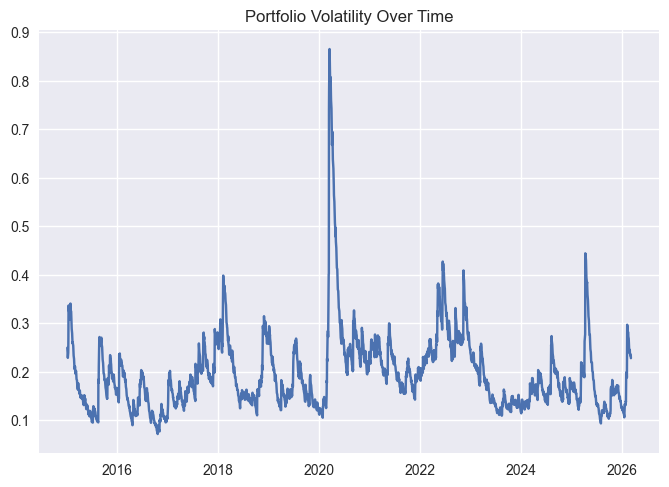

In [8]:
cov_matrices = ewma_covariance(returns)

weights = np.ones(len(returns.columns)) / len(returns.columns)

portfolio_vol_series = [
    portfolio_volatility(cov, weights) for cov in cov_matrices
]

plt.plot(returns.index, portfolio_vol_series)
plt.title("Portfolio Volatility Over Time")
plt.show()